# GoogLeNet

![GoogLeNet](./images/GoogLeNet.png)

## Inception 块

使用多种路径（卷积核大小、超参数、池化）并行提取特征，最后将结果合并。

![Inception](./images/Inception_block.svg)

### 路径分解
白色块变化通道数，蓝色块真正提取特征。
- 路径1: 不考虑空间，只看通道特征
- 路径2: 1x1卷积降维，3x3 卷积提取小视野特征
- 路径3: 1x1卷积降维，5x5 卷积提取大视野特征
- 路径4: MaxPooling 保留强响应特征，1x1卷积变换通道

### 路径合并
输入与输出高宽相同，所有路径在“通道维度”上 concat。

### 复杂度
|           | 参数量 | 计算量 |
|-----------|--------|--------|
| Inception | 0.16M  | 128M   |
| 3x3 Conv  | 0.44M  | 346M   |
| 5x5 Conv  | 1.22M  | 963M   |

大量使用 1x1 卷积降维，复杂度远低于直接使用 3x3 或 5x5 多通道卷积。

## 架构
![Inception V3](./images/inception-full.svg)

## 变种
- Inception-v2: 使用 BatchNorm
- Inception-v3: 修改 Inception 块
  - 替换 5x5 卷积为多个 3x3 卷积（来自 VGG）
  - 替换 5x5 卷积为 1x7 + 7x1 卷积（一些只看列一些只看行）
  - 替换 3x3 卷积为 1x3 + 3x1 卷积
  - 更深
- Inception-v4: 使用残差连接


## 实现


In [1]:
import torch
from torch import nn
from torch.nn import functional as F
from torchinfo import summary
import util

/root/autodl-tmp/envs/daily_learning/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Inception 块


In [2]:
class Inception(nn.Module):
    def __init__(self, in_channels: int, c1: int, c2: tuple[int, int], c3: tuple[int, int], c4: int, **kwargs):
        """Inception 块
        :param in_channels: 输入通道数
        :param c1: 路径 1 的 1x1 卷积输出通道数
        :param c2: 路径 2 的两层通道数，c2[0] 是 1x1 卷积的输出通道数，c2[1] 是 3x3 卷积的输出通道数
        :param c3: 路径 3 的两层通道数，c3[0] 是 1x1 卷积的输出通道数，c3[1] 是 5x5 卷积的输出通道数
        :param c4: 路径 4 的 1x1 卷积输出通道数
        """
        super(Inception, self).__init__(**kwargs)
        # path 1
        self.p1_1 = nn.Conv2d(in_channels, c1, kernel_size=1) # 1x1 卷积
        # path 2
        self.p2_1 = nn.Conv2d(in_channels, c2[0], kernel_size=1) # 1x1 卷积
        self.p2_2 = nn.Conv2d(c2[0], c2[1], kernel_size=3, padding=1) # 3x3 卷积
        # path 3
        self.p3_1 = nn.Conv2d(in_channels, c3[0], kernel_size=1) # 1x1 卷积
        self.p3_2 = nn.Conv2d(c3[0], c3[1], kernel_size=5, padding=2) # 5x5 卷积
        # path 4
        self.p4_1 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1) # 3x3 最大池化
        self.p4_2 = nn.Conv2d(in_channels, c4, kernel_size=1) # 1x1 卷积

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        p1 = F.relu(self.p1_1(X))
        p2 = F.relu(self.p2_2(F.relu(self.p2_1(X))))
        p3 = F.relu(self.p3_2(F.relu(self.p3_1(X))))
        p4 = F.relu(self.p4_2(self.p4_1(X)))
        return torch.cat((p1, p2, p3, p4), dim=1) # 在通道维度上 concat

实现每个 Stage

真 tm 多


In [3]:
b1 = nn.Sequential(
    nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
)
b2 = nn.Sequential(
    nn.Conv2d(64, 64, kernel_size=1),
    nn.ReLU(),
    nn.Conv2d(64, 192, kernel_size=3, padding=1),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
)
b3 = nn.Sequential(
    Inception(192, 64, (96, 128), (16, 32), 32),
    Inception(256, 128, (128, 192), (32, 96), 64),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
)
b4 = nn.Sequential(
    Inception(480, 192, (96, 208), (16, 48), 64),
    Inception(512, 160, (112, 224), (24, 64), 64),
    Inception(512, 128, (128, 256), (24, 64), 64),
    Inception(512, 112, (144, 288), (32, 64), 64),
    Inception(528, 256, (160, 320), (32, 128), 128),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
)
b5 = nn.Sequential(
    Inception(832, 256, (160, 320), (32, 128), 128),
    Inception(832, 384, (192, 384), (48, 128), 128),
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten()
)

接上 MLP


In [4]:
net = nn.Sequential(
    b1, b2, b3, b4, b5,
    nn.Linear(1024, 10)
)

In [5]:
summary(net, input_size=(1, 1, 96, 96), col_names=["input_size", "output_size", "num_params"], depth=2)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
Sequential                               [1, 1, 96, 96]            [1, 10]                   --
├─Sequential: 1-1                        [1, 1, 96, 96]            [1, 64, 24, 24]           --
│    └─Conv2d: 2-1                       [1, 1, 96, 96]            [1, 64, 48, 48]           3,200
│    └─ReLU: 2-2                         [1, 64, 48, 48]           [1, 64, 48, 48]           --
│    └─MaxPool2d: 2-3                    [1, 64, 48, 48]           [1, 64, 24, 24]           --
├─Sequential: 1-2                        [1, 64, 24, 24]           [1, 192, 12, 12]          --
│    └─Conv2d: 2-4                       [1, 64, 24, 24]           [1, 64, 24, 24]           4,160
│    └─ReLU: 2-5                         [1, 64, 24, 24]           [1, 64, 24, 24]           --
│    └─Conv2d: 2-6                       [1, 64, 24, 24]           [1, 192, 24, 24]          110,784
│    └─MaxPool2d: 2-7   

训练


loss 0.297, train acc 0.889, test acc 0.882
2977.4 examples/sec on cuda:0


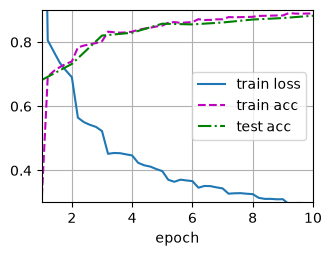

In [6]:
batch_size = 50
lr = 0.01
num_epochs = 10
train_iter, test_iter = util.data.load_data_fashion_mnist(batch_size, resize=96)
util.train.train_ch6(net, train_iter, test_iter, num_epochs, lr, device=util.try_gpu())

In [9]:
torch.save(net.state_dict(), "./models/GoogLeNet.pth")